In [1]:
# keras imports
from keras.applications.vgg16 import VGG16, preprocess_input
from keras_preprocessing import image
from keras.models import Model
from keras.layers import Input

# other imports
from sklearn.linear_model import LogisticRegression
from IPython.display import Image, display
import numpy as np
import os
import json
import pickle

In [2]:
config={
  "model"           : "vgg16",
  "weights"         : "imagenet",

  "classifier_path" : "/Users/RAHUL/Downloads/car-damage-check3/classifier.pickle",

}

In [3]:
# load the trained logistic regression classifier
print ("[INFO] loading the classifier...")
classifier = pickle.load(open(config["classifier_path"], 'rb'))

# pretrained models needed to perform feature extraction on test data too!
if config["model"] == "vgg16":
	base_model = VGG16(weights=config["weights"])
	model = Model(base_model.input, base_model.get_layer('fc1').output)
	image_size = (224, 224)

else:
	base_model = None

[INFO] loading the classifier...


2023-04-18 11:48:54.226790: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
# Pre-proces the image and make predictions
def predict_carDamageSeverity(car_image):
    img= image.load_img(car_image, target_size=image_size)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = preprocess_input(x)
    feature = model.predict(x)
    flat = feature.flatten()
    flat = np.expand_dims(flat, axis=0)
    preds = classifier.predict(flat)
    return(preds)

label_check = ['Minor Damage', 'Moderate Damage', 'Severe Damage']

# Determines the severity of the damage (minor, moderate and severe).

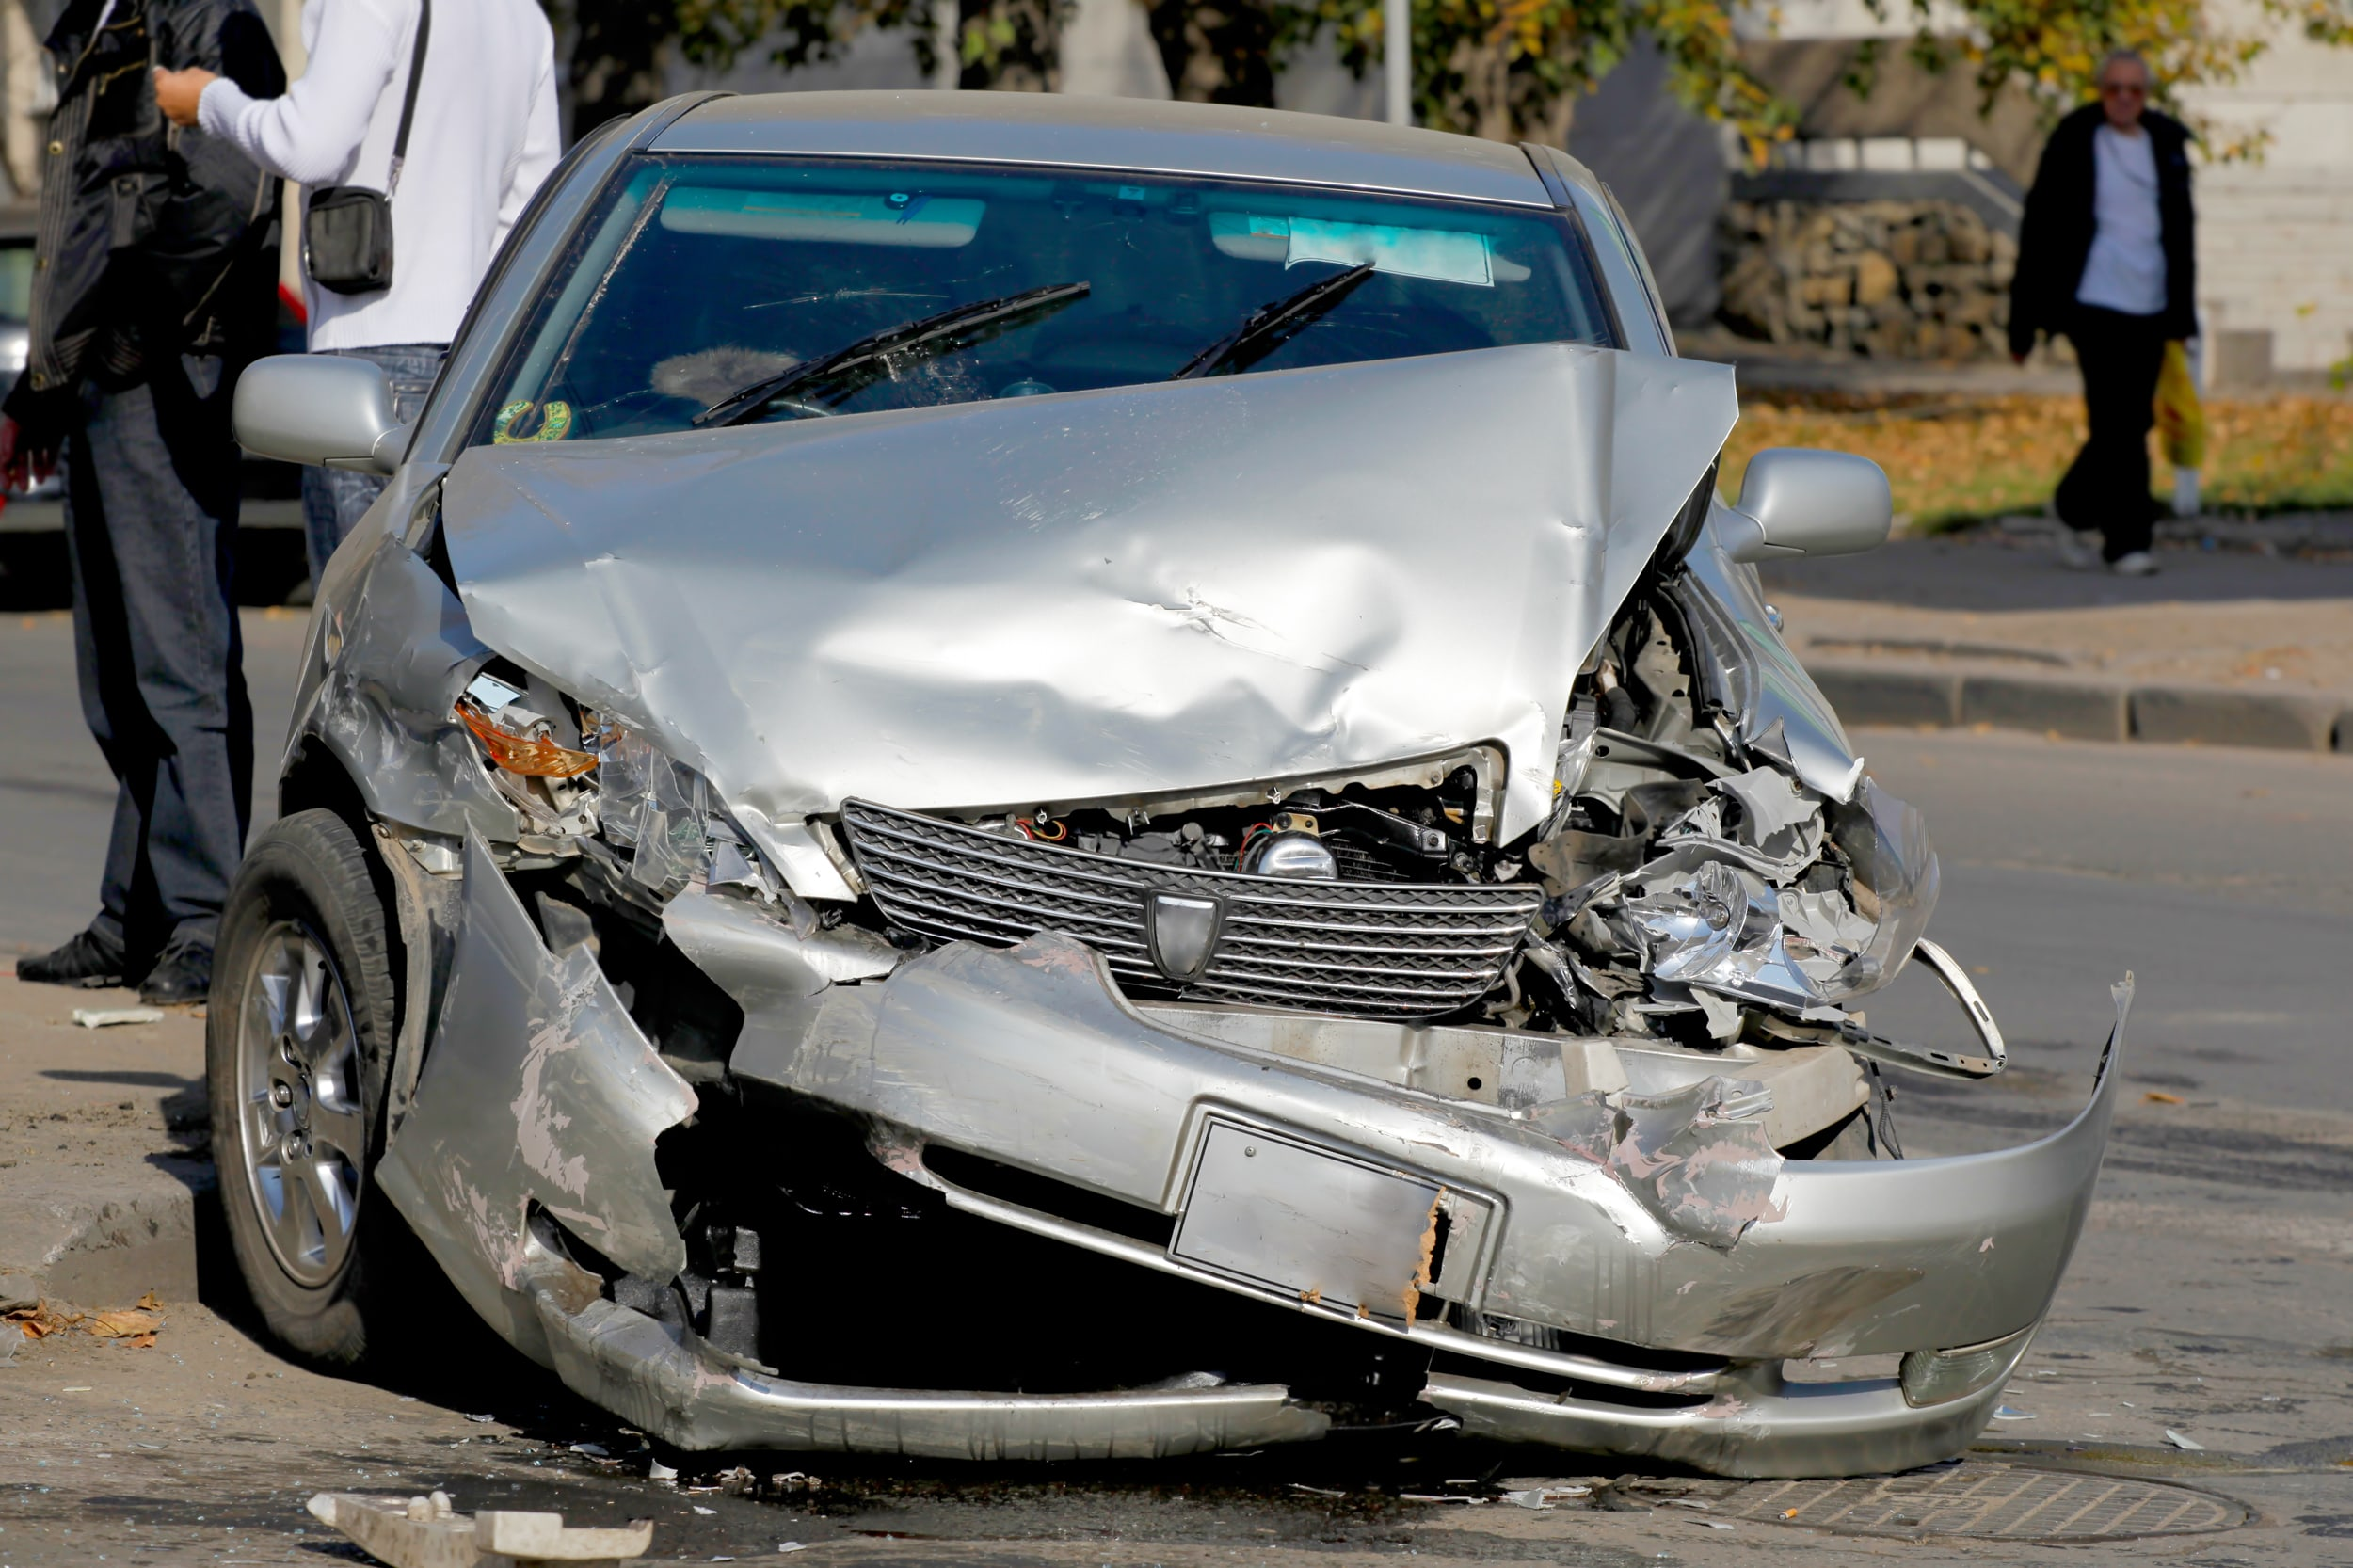

1/1 [==============================] - 0s 364ms/step


'Severe Damage'

In [5]:
# Display image 
car_image = 'Image5.jpeg'
display(Image(filename=car_image))

# Make predictions
preds = predict_carDamageSeverity(car_image)

# Check if the car is damaged or not.
label_check[preds[0]]

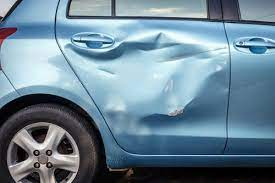

1/1 [==============================] - 0s 205ms/step


'Moderate Damage'

In [7]:
# Display image 
car_image = 'Image16.jpeg'
display(Image(filename=car_image))

# Make predictions
preds = predict_carDamageSeverity(car_image)

# Check if the car is damaged or not.
label_check[preds[0]]

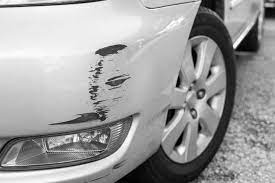

1/1 [==============================] - 0s 200ms/step


'Minor Damage'

In [8]:
# Display image 
car_image = 'Image10.jpeg'
display(Image(filename=car_image))

# Make predictions
preds = predict_carDamageSeverity(car_image)

# Check if the car is damaged or not.
label_check[preds[0]]

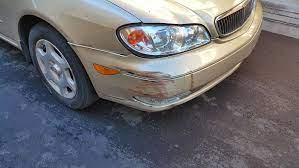

1/1 [==============================] - 0s 207ms/step


'Minor Damage'

In [9]:
# Display image 
car_image = 'Image11.jpeg'
display(Image(filename=car_image))

# Make predictions
preds = predict_carDamageSeverity(car_image)

# Check if the car is damaged or not.
label_check[preds[0]]

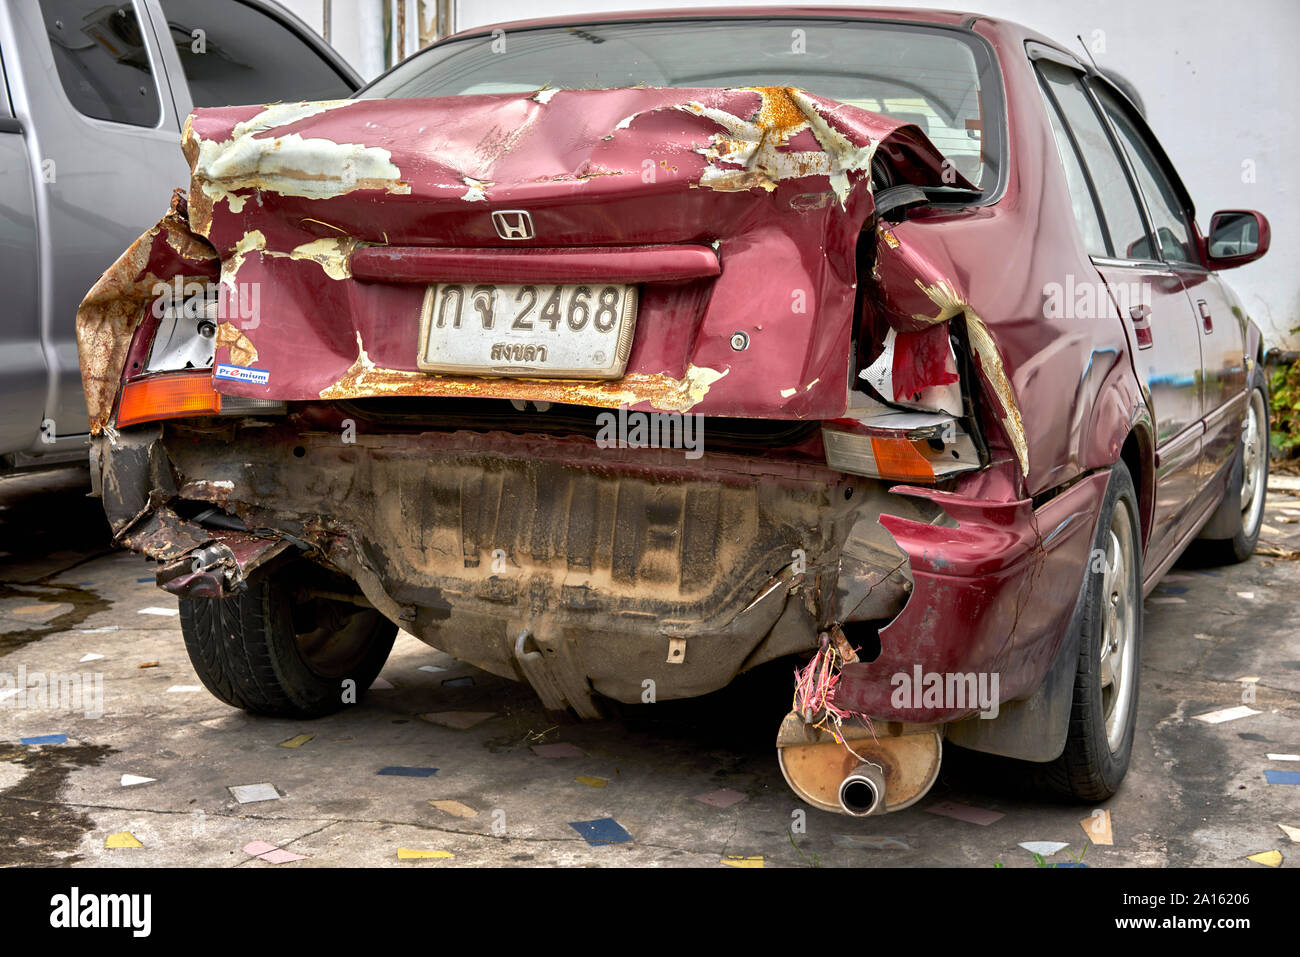

1/1 [==============================] - 0s 208ms/step


'Severe Damage'

In [10]:
# Display image 
car_image = 'Image7.jpeg'
display(Image(filename=car_image))

# Make predictions
preds = predict_carDamageSeverity(car_image)

# Check if the car is damaged or not.
label_check[preds[0]]